In [1]:
import os

folders = [
    "data2/raw/skin",
    "data2/processed",
    "models2",
    "outputs2"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders ready!")

Folders ready!


In [2]:
import os

base_path = "data2/raw/skin"

print("Folders:", os.listdir(base_path))

Folders: ['images1', 'images2', 'metadata.csv']


In [3]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import random

In [4]:
df = pd.read_csv("data2/raw/skin/metadata.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
label_map = {label: idx for idx, label in enumerate(df['dx'].unique())}
df['label'] = df['dx'].map(label_map)

print(label_map)

{'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [7]:
IMG_SIZE = 128

IMAGE_PATHS = [
    "data2/raw/skin/images1",
    "data2/raw/skin/images2"
]

In [8]:
data = []

for i in tqdm(range(len(df))):
    img_id = df.iloc[i]['image_id']
    label = df.iloc[i]['label']

    img_path = None

    for folder in IMAGE_PATHS:
        temp_path = os.path.join(folder, img_id + ".jpg")
        if os.path.exists(temp_path):
            img_path = temp_path
            break

    try:
        img_array = cv2.imread(img_path)
    

        resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

        data.append([resized, label])
    except:
        pass

print("Total images loaded:", len(data))

100%|████████████████████████████████████████████████████████████████████████████| 10015/10015 [02:11<00:00, 76.19it/s]

Total images loaded: 10015


In [9]:
random.shuffle(data)

In [10]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)

Shape: (10015, 128, 128, 3)


In [11]:
X = X.astype("float32") / 255.0

In [12]:
print("X shape:", X.shape)
print("Single image:", X[0].shape)
print("Min:", X.min(), "Max:", X.max())

X shape: (10015, 128, 128, 3)
Single image: (128, 128, 3)
Min: 0.0 Max: 1.0


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (7010, 128, 128, 3)
Val: (1502, 128, 128, 3)
Test: (1503, 128, 128, 3)


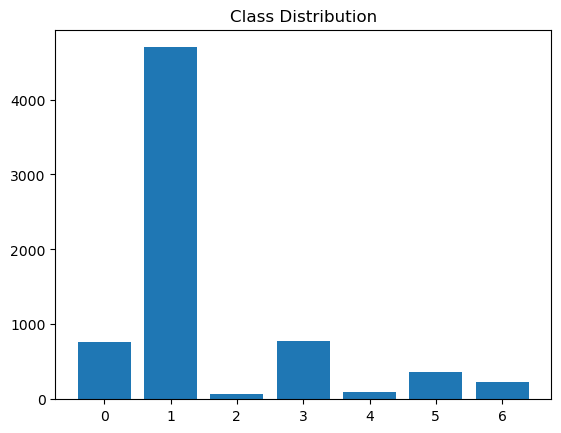

{'bkl': np.int64(762), 'nv': np.int64(4697), 'df': np.int64(74), 'mel': np.int64(780), 'vasc': np.int64(103), 'bcc': np.int64(368), 'akiec': np.int64(226)}


In [14]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

plt.bar(range(len(label_map)), counts)
plt.title("Class Distribution")
plt.show()

print(dict(zip(label_map.keys(), counts)))

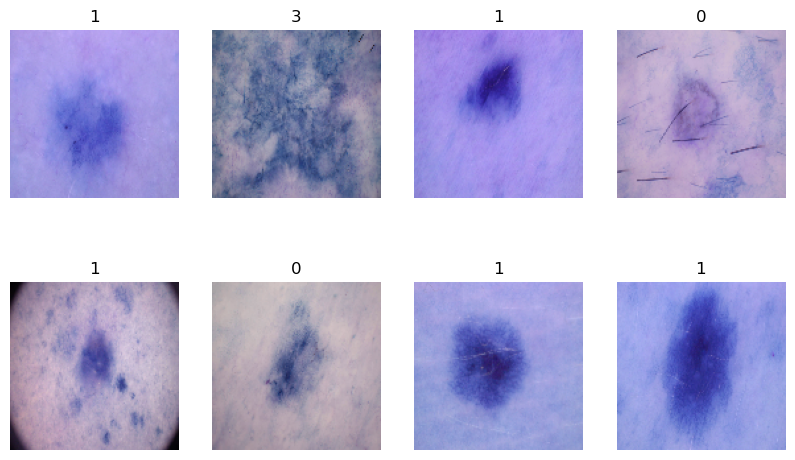

In [17]:
plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [19]:
import pickle

pickle.dump(X_train, open("data2/processed/skin_X_train.pkl", "wb"))
pickle.dump(y_train, open("data2/processed/skin_y_train.pkl", "wb"))

pickle.dump(X_val, open("data2/processed/skin_X_val.pkl", "wb"))
pickle.dump(y_val, open("data2/processed/skin_y_val.pkl", "wb"))

pickle.dump(X_test, open("data2/processed/skin_X_test.pkl", "wb"))
pickle.dump(y_test, open("data2/processed/skin_y_test.pkl", "wb"))

print("Saved!")

Saved!


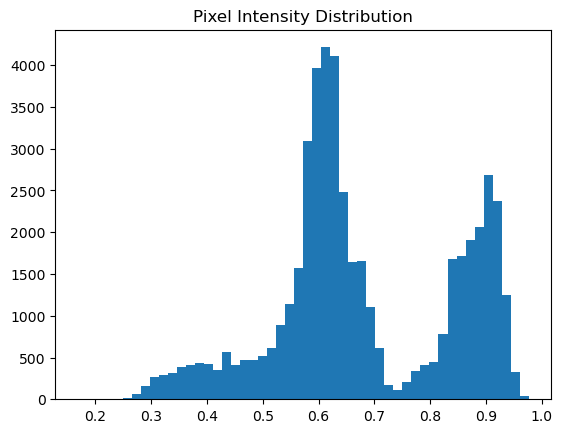

In [20]:
plt.figure()
plt.hist(X_train[0].ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [21]:

class_names = list(label_map.keys())
for i, cls in enumerate(class_names):
    print(f"{cls}: {(y_train == i).sum()} images")

bkl: 762 images
nv: 4697 images
df: 74 images
mel: 780 images
vasc: 103 images
bcc: 368 images
akiec: 226 images


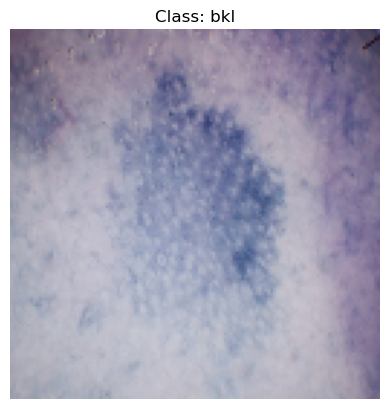

In [23]:
import random

idx = random.randint(0, len(X_train)-1)

plt.imshow(X_train[idx])
plt.title(f"Class: {class_names[y_train[idx]]}")
plt.axis('off')
plt.show()

In [24]:
# Check imbalance ratio
class_names = list(label_map.keys())
print("\nClass imbalance ratio:")
total = len(y_train)

for i, cls in enumerate(class_names):
    count = (y_train == i).sum()
    print(f"{cls}: {count/total:.2%}")


Class imbalance ratio:
bkl: 10.87%
nv: 67.00%
df: 1.06%
mel: 11.13%
vasc: 1.47%
bcc: 5.25%
akiec: 3.22%


In [25]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=120,   # small → fast
    max_depth=10,      # limit depth → faster
    random_state=42
)

rf.fit(X_train_flat, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",120
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [29]:
from sklearn.metrics import accuracy_score

# Train accuracy
y_train_pred = rf.predict(X_train_flat)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy
y_test_pred = rf.predict(X_test_flat)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8940085592011412
Test Accuracy: 0.7125748502994012
